# Deep Learning Models — TON_IoT NLP Dataset
### Models: TextCNN | Bi-LSTM | Bi-GRU | Bi-LSTM + Attention | CNN-LSTM Hybrid
**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, MCC, Cohen's Kappa, Training Curves

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, GRU, Dense, Dropout,
    Conv1D, GlobalMaxPooling1D, Input, Concatenate, Multiply,
    Activation, Lambda, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    classification_report, confusion_matrix
)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus if gpus else 'None — using CPU')

TensorFlow version: 2.20.0
GPUs available: None — using CPU


In [2]:
df = pd.read_csv('TON_IoT_NLP_Dataset.csv')
texts = df['text'].astype(str)
labels = df['label'].astype(int)

print('Dataset shape:', df.shape)
print('Label distribution:\n', labels.value_counts())

Dataset shape: (211043, 3)
Label distribution:
 label
1    161043
0     50000
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# Tokenization
MAX_WORDS = 20000
MAX_LEN   = 128
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

y_train = np.array(y_train)
y_test  = np.array(y_test)

print('X_train_pad shape:', X_train_pad.shape)
print('X_test_pad shape: ', X_test_pad.shape)

X_train_pad shape: (168834, 128)
X_test_pad shape:  (42209, 128)


In [4]:
# ─────────────────────────────────────────────────────────────
# Callbacks & Evaluation Utility
# ─────────────────────────────────────────────────────────────
results_table = []

def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

def evaluate_dl_model(name, model, X_tr, X_te, y_tr, y_te, epochs=10, batch_size=256):
    print(f'\n{"="*60}\n  Training: {name}\n{"="*60}')
    model.summary()

    t0 = time.time()
    history = model.fit(
        X_tr, y_tr, epochs=epochs, batch_size=batch_size,
        validation_split=0.1, callbacks=get_callbacks(), verbose=1
    )
    train_time = time.time() - t0

    # Predict
    t1 = time.time()
    y_prob = model.predict(X_te, batch_size=512).ravel()
    infer_time = time.time() - t1
    y_pred = (y_prob > 0.5).astype(int)

    # Metrics
    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, average='weighted')
    rec   = recall_score(y_te, y_pred, average='weighted')
    f1    = f1_score(y_te, y_pred, average='weighted')
    auc   = roc_auc_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    kappa = cohen_kappa_score(y_te, y_pred)
    params = model.count_params()

    print(f'\n{"─"*60}')
    print(f'  Results — {name}')
    print(f'{"─"*60}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (weighted)')
    print(f'  Recall    : {rec:.4f}  (weighted)')
    print(f'  F1-Score  : {f1:.4f}  (weighted)')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}')
    print(f"  Cohen's κ : {kappa:.4f}")
    print(f'  Parameters: {params:,}')
    print(f'  Train Time: {train_time:.1f}s  |  Infer Time: {infer_time:.3f}s')
    print(f'\nClassification Report:')
    print(classification_report(y_te, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {name}')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    # Training curves
    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].plot(history.history['loss'], label='Train Loss', linestyle='--')
    axes[1].plot(history.history['val_loss'], label='Val Loss', linestyle='--')
    axes[1].set_title(f'Training Curves — {name}')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'dl_{name.replace(" ","_")}.png', dpi=150)
    plt.show()

    results_table.append({
        'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1-Score': round(f1,4),
        'ROC-AUC': round(auc,4), 'MCC': round(mcc,4),
        "Cohen's Kappa": round(kappa,4),
        'Params': params, 'Train Time(s)': round(train_time,1)
    })
    return history


  Training: TextCNN


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 127, 128)  │     32,896 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 126, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 125, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,708,225 (10.33 MB)

 Trainable params: 2,708,225 (10.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 43s 70ms/step - accuracy: 0.9280 - loss: 0.1668 - val_accuracy: 0.9379 - val_loss: 0.1372 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 66s 111ms/step - accuracy: 0.9367 - loss: 0.1428 - val_accuracy: 0.9382 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 48s 81ms/step - accuracy: 0.9376 - loss: 0.1407 - val_accuracy: 0.9391 - val_loss: 0.1342 - learning_rate: 0.0010
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 60s 100ms/step - accuracy: 0.9378 - loss: 0.1393 - val_accuracy: 0.9391 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9387 - loss: 0.1382 - val_accuracy: 0.9372 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 46s 77ms/step - accuracy: 0.9386 - loss: 0.1377 - val_accuracy: 0.9360 - val_loss: 0.1341 - learning_rate: 0.0010
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 46s 77ms/step - accuracy: 0.9388 -

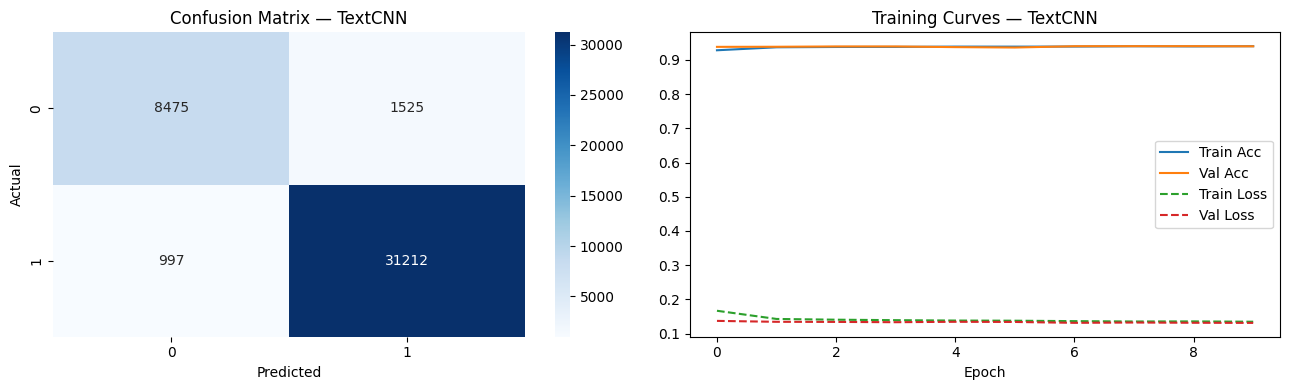

In [5]:
# ── 1. TextCNN ──────────────────────────────────────────────
# Parallel Conv1D with multiple filter sizes (Kim, 2014)

inp = Input(shape=(MAX_LEN,))
emb = Embedding(MAX_WORDS, EMBED_DIM)(inp)

convs = []
for fs in [2, 3, 4]:   # filter sizes
    c = Conv1D(128, fs, activation='relu', padding='valid')(emb)
    c = GlobalMaxPooling1D()(c)
    convs.append(c)

x = Concatenate()(convs)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid')(x)

model_cnn = Model(inp, out)
model_cnn.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

evaluate_dl_model('TextCNN', model_cnn, X_train_pad, X_test_pad, y_train, y_test)


  Training: Bi-LSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 122s 201ms/step - accuracy: 0.9227 - loss: 0.1791 - val_accuracy: 0.9382 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 116s 195ms/step - accuracy: 0.9380 - loss: 0.1410 - val_accuracy: 0.9385 - val_loss: 0.1350 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 125s 210ms/step - accuracy: 0.9389 - loss: 0.1381 - val_accuracy: 0.9389 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 158s 237ms/step - accuracy: 0.9388 - loss: 0.1363 - val_accuracy: 0.9387 - val_loss: 0.1360 - learning_rate: 0.0010
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 144s 240ms/step - accuracy: 0.9398 - loss: 0.1347 - val_accuracy: 0.9388 - val_loss: 0.1336 - learning_rate: 5.0000e-04
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 207s 247ms/step - accuracy: 0.9398 - loss: 0.1345 - val_accuracy: 0.9369 - val_loss: 0.1335 - learning_rate: 5.0000e-04
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 146s 245ms/step 

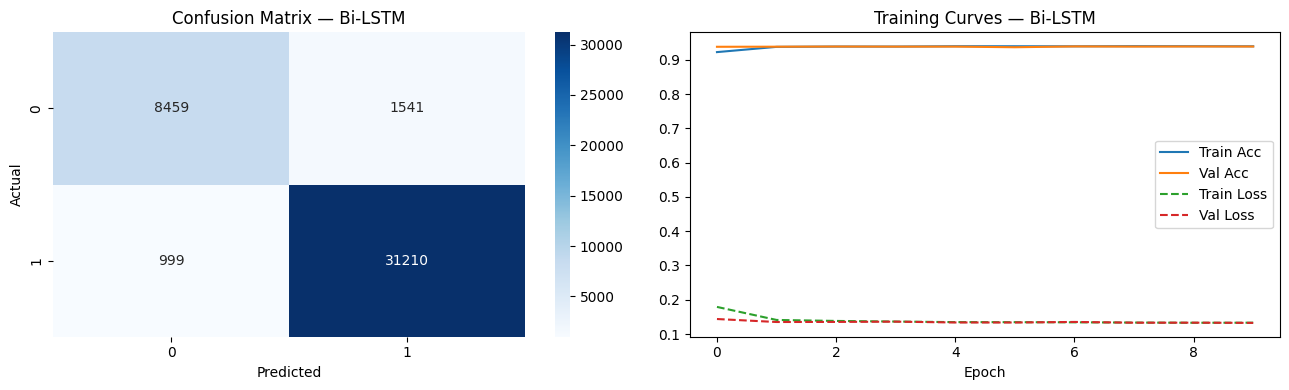

In [6]:
# ── 2. Bi-LSTM ──────────────────────────────────────────────
model_bilstm = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_bilstm.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

evaluate_dl_model('Bi-LSTM', model_bilstm, X_train_pad, X_test_pad, y_train, y_test)


  Training: Bi-GRU


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 160s 264ms/step - accuracy: 0.9202 - loss: 0.1853 - val_accuracy: 0.9343 - val_loss: 0.1458 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 152s 256ms/step - accuracy: 0.9371 - loss: 0.1424 - val_accuracy: 0.9378 - val_loss: 0.1373 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 201s 254ms/step - accuracy: 0.9381 - loss: 0.1398 - val_accuracy: 0.9378 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 206s 261ms/step - accuracy: 0.9389 - loss: 0.1376 - val_accuracy: 0.9384 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 152s 256ms/step - accuracy: 0.9392 - loss: 0.1369 - val_accuracy: 0.9386 - val_loss: 0.1340 - learning_rate: 0.0010
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 153s 258ms/step - accuracy: 0.9393 - loss: 0.1360 - val_accuracy: 0.9389 - val_loss: 0.1338 - learning_rate: 0.0010
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 202s 258ms/step - accura

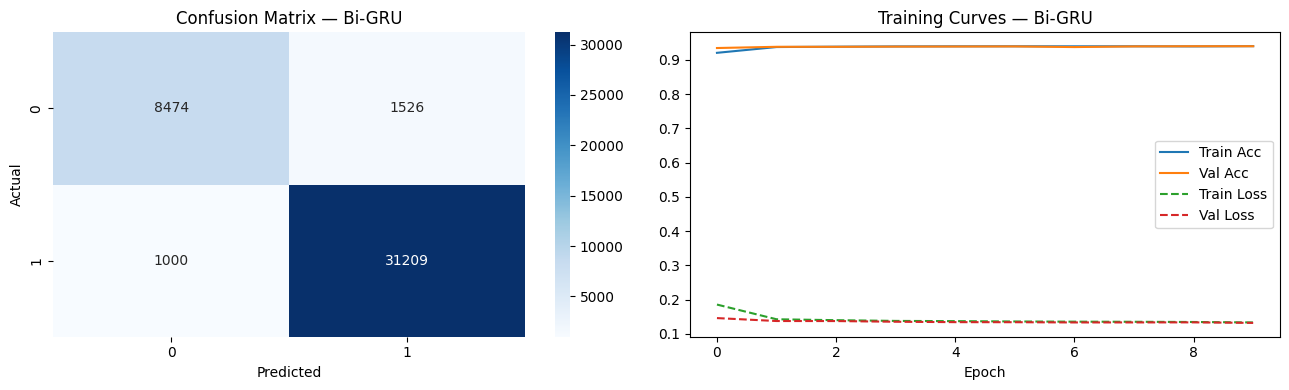

In [7]:
# ── 3. Bi-GRU ───────────────────────────────────────────────
model_bigru = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_bigru.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

evaluate_dl_model('Bi-GRU', model_bigru, X_train_pad, X_test_pad, y_train, y_test)



  Training: Bi-LSTM + Attention


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 128, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ (None, 128)            │         8,321 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,266 (10.17 MB)

 Trainable params: 2,667,266 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 129s 212ms/step - accuracy: 0.9179 - loss: 0.1844 - val_accuracy: 0.9375 - val_loss: 0.1366 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 124s 209ms/step - accuracy: 0.9390 - loss: 0.1377 - val_accuracy: 0.9386 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 113s 190ms/step - accuracy: 0.9396 - loss: 0.1359 - val_accuracy: 0.9387 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 120s 202ms/step - accuracy: 0.9396 - loss: 0.1352 - val_accuracy: 0.9390 - val_loss: 0.1337 - learning_rate: 0.0010
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 122s 206ms/step - accuracy: 0.9397 - loss: 0.1335 - val_accuracy: 0.9389 - val_loss: 0.1381 - learning_rate: 0.0010
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 126s 212ms/step - accuracy: 0.9400 - loss: 0.1327 - val_accuracy: 0.9394 - val_loss: 0.1346 - learning_rate: 0.0010
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 157s 264ms/step - accura

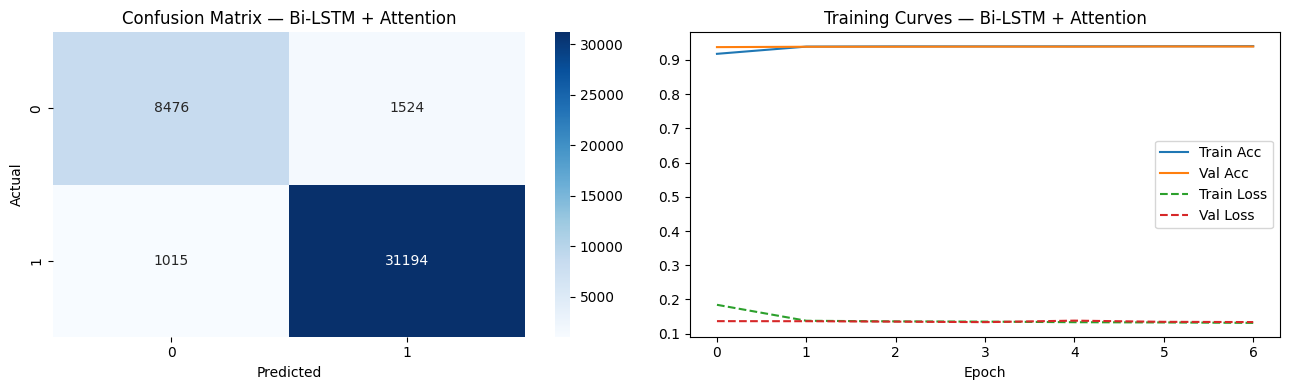

In [8]:
# ── 4. Bi-LSTM + Attention ──────────────────────────────────
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer

class BahdanauAttention(Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = Dense(units)
        self.V = Dense(1)

    def call(self, hidden_states):
        score = self.V(tf.nn.tanh(self.W(hidden_states)))
        weights = tf.nn.softmax(score, axis=1)
        context = weights * hidden_states
        context = tf.reduce_sum(context, axis=1)
        return context

inp = Input(shape=(MAX_LEN,))
x   = Embedding(MAX_WORDS, EMBED_DIM)(inp)
x   = Bidirectional(LSTM(64, return_sequences=True))(x)
x   = Dropout(0.3)(x)
x   = BahdanauAttention(64)(x)
out = Dense(1, activation='sigmoid')(x)

model_attn = Model(inp, out)
model_attn.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

evaluate_dl_model('Bi-LSTM + Attention', model_attn, X_train_pad, X_test_pad, y_train, y_test)


  Training: CNN-LSTM Hybrid


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 97s 157ms/step - accuracy: 0.9242 - loss: 0.1717 - val_accuracy: 0.9385 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 153s 175ms/step - accuracy: 0.9388 - loss: 0.1380 - val_accuracy: 0.9359 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 107s 116ms/step - accuracy: 0.9397 - loss: 0.1368 - val_accuracy: 0.9388 - val_loss: 0.1351 - learning_rate: 0.0010
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 0.9396 - loss: 0.1353 - val_accuracy: 0.9393 - val_loss: 0.1340 - learning_rate: 0.0010
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 56s 94ms/step - accuracy: 0.9398 - loss: 0.1347 - val_accuracy: 0.9392 - val_loss: 0.1336 - learning_rate: 0.0010
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 0.9400 - loss: 0.1338 - val_accuracy: 0.9397 - val_loss: 0.1317 - learning_rate: 0.0010
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 54s 90ms/step - accuracy: 0.939

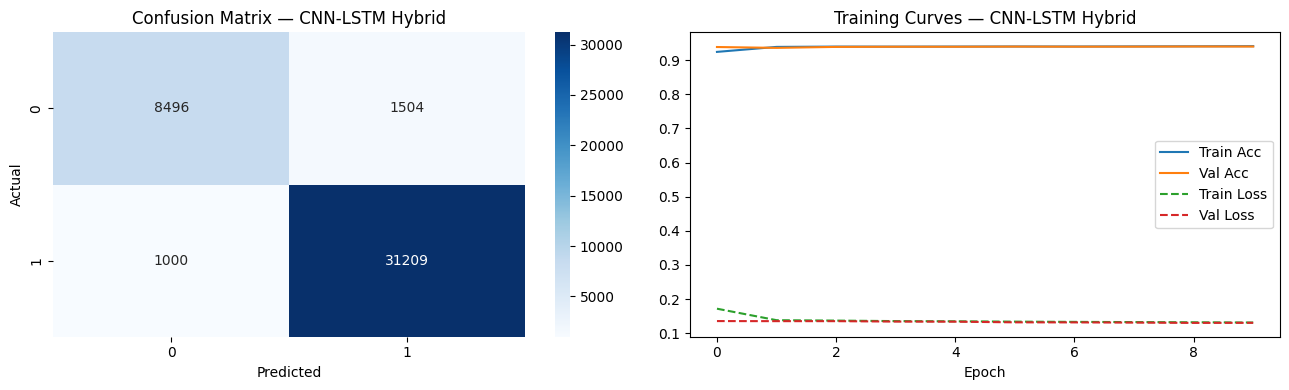

In [9]:
# ── 5. CNN-LSTM Hybrid ──────────────────────────────────────
from tensorflow.keras.layers import MaxPooling1D

model_cnnlstm = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_cnnlstm.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

evaluate_dl_model('CNN-LSTM Hybrid', model_cnnlstm, X_train_pad, X_test_pad, y_train, y_test)

In [10]:
# ── SUMMARY TABLE ────────────────────────────────────────────
results_df = pd.DataFrame(results_table).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('\n' + '='*100)
print('         COMPARATIVE RESULTS TABLE — DL MODELS (TON_IoT NLP Dataset)')
print('='*100)
print(results_df.to_string(index=False))
print('='*100)

results_df.to_csv('dl_results.csv', index=False)
print('Saved to dl_results.csv')


         COMPARATIVE RESULTS TABLE — DL MODELS (TON_IoT NLP Dataset)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC    MCC  Cohen's Kappa  Params  Train Time(s)
    CNN-LSTM Hybrid    0.9407     0.9400  0.9407    0.9401   0.9837 0.8335         0.8330 2740993          740.7
            TextCNN    0.9402     0.9395  0.9402    0.9397   0.9834 0.8322         0.8317 2708225          492.7
             Bi-GRU    0.9402     0.9394  0.9402    0.9396   0.9831 0.8319         0.8314 2634625         1832.9
Bi-LSTM + Attention    0.9398     0.9391  0.9398    0.9393   0.9829 0.8311         0.8307 2667266          935.7
            Bi-LSTM    0.9398     0.9391  0.9398    0.9392   0.9833 0.8309         0.8304 2658945         1624.0
Saved to dl_results.csv


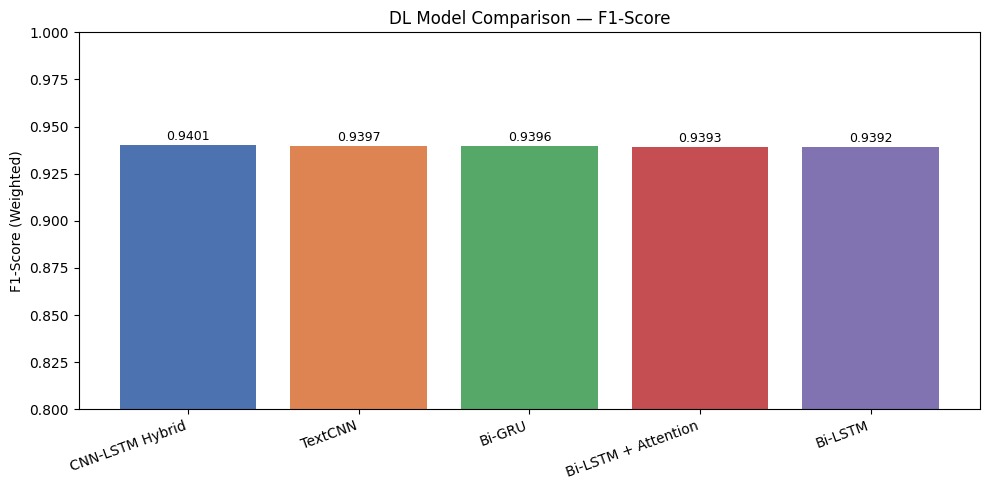

In [11]:
# ── F1 Bar Chart Comparison ─────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
bars = plt.bar(results_df['Model'], results_df['F1-Score'], color=colors)
plt.ylim(0.8, 1.0)
plt.ylabel('F1-Score (Weighted)')
plt.title('DL Model Comparison — F1-Score')
for bar, val in zip(bars, results_df['F1-Score']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('dl_comparison.png', dpi=150)
plt.show()

## Notes for Research Paper
- Used **EarlyStopping** (patience=3) and **ReduceLROnPlateau** to prevent overfitting.
- All models trained with **80/10/10** split (train/val/test).
- **MCC** and **Cohen's Kappa** are critical for imbalanced security datasets.
- Report model **parameter count** to justify complexity vs. performance tradeoff.
- **Attention weights** can be visualized for explainability (XAI section).
